## Section 0: Missing teeth & Displacement dari foto frontal

Reuse model segmentasi frontal (`09_yolo_seg_frontal_pilot.ipynb`) buat ukur 2 komponen DHC terakhir yang belum dikerjain: **Missing** (gigi hilang) dan **Displacement** (gigi bergeser/rotasi dari posisi lengkung alami).

Beda dari overjet/overbite/Angle (yang butuh identitas FDI pasti dari anchor kaninus), dua komponen ini **cuma butuh posisi RELATIF antar gigi bertetangga** dalam 1 lengkung -- nggak perlu tau ini gigi nomor berapa persisnya, cukup "lengkung atas/bawah" + urutan kiri-kanan. Makanya nggak perlu detector kaninus versi frontal, langsung jalan dari segmentasi + kmeans upper/lower yang udah ada.

**Missing**: ukur celah antar gigi bertetangga, celah yang jauh lebih lebar dari lebar gigi normal = kemungkinan ada gigi hilang di situ.

**Displacement**: fit garis lengkung (kurva kuadratik) ke semua gigi 1 lengkung, gigi yang menyimpang jauh dari garis itu = kemungkinan bergeser/rotasi.

## Section 1: Setup

In [8]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
from sklearn.cluster import KMeans

import io
from IPython.display import display, Image as IPImage

## Section 2: Load model segmentasi frontal (`09_yolo_seg_frontal_pilot.ipynb`)

In [9]:
SEG_WEIGHTS = Path("runs/segment/frontal_pilot_runs/baseline_seg/weights/best.pt")
assert SEG_WEIGHTS.exists(), f"Model belum ada di {SEG_WEIGHTS} -- run training di 09_yolo_seg_frontal_pilot.ipynb dulu"

seg_model = YOLO(str(SEG_WEIGHTS))
SEG_CONF, SEG_IOU = 0.5, 0.4
print("model segmentasi frontal dimuat:", SEG_WEIGHTS)

model segmentasi frontal dimuat: runs/segment/frontal_pilot_runs/baseline_seg/weights/best.pt


## Section 3: Helper -- segmentasi & split lengkung

Sama persis pola yang dipakai di notebook lateral (`06`/`07`), cuma modelnya beda (frontal).

In [10]:
def instance_features_from_mask(pts):
    x0, y0 = pts.min(axis=0)
    x1, y1 = pts.max(axis=0)
    return {"points": pts, "centroid": [float((x0 + x1) / 2), float((y0 + y1) / 2)], "bbox": (x0, y0, x1, y1),
            "width": x1 - x0, "height": y1 - y0}


def filter_spurious_instances(feats, min_area_ratio=0.15):
    def area(f):
        x0, y0, x1, y1 = f["bbox"]
        return (x1 - x0) * (y1 - y0)
    areas = [area(f) for f in feats]
    median_area = np.median(areas)
    return [f for f, a in zip(feats, areas) if a >= median_area * min_area_ratio]


def split_arch_kmeans(feats):
    """FIX: kmeans langsung ke posisi-y mentah gagal khusus di foto frontal -- gigi depan
    atas-bawah bisa deket banget secara vertikal (beda dari lateral yg selalu terpisah
    jelas), jadi kmeans nge-lump sebagian gigi bawah depan ke cluster "upper" (ditemukan
    nyata di salah satu foto unseen). Fix: fit kurva kuadratik (y = f(x)) ke SEMUA gigi
    dulu -- kurva ini otomatis jadi semacam "garis tengah" antara lengkung atas & bawah
    (karena ditarik dari titik kedua lengkung sekaligus). Baru cluster RESIDUAL (gigi di
    atas garis vs di bawah garis), bukan posisi-y mentah -- ini yg benar secara anatomis,
    divalidasi visual ke 6 foto unseen (termasuk 2 yang tadinya salah)."""
    if len(feats) < 4:
        # fallback data terlalu sedikit buat fit kurva -- kmeans y biasa masih oke buat kasus ini
        if len(feats) < 2:
            return list(feats), []
        ys = np.array([[f["centroid"][1]] for f in feats])
        km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(ys)
        upper_label = int(np.argmin(km.cluster_centers_.flatten()))
        upper = [f for f, l in zip(feats, km.labels_) if l == upper_label]
        lower = [f for f, l in zip(feats, km.labels_) if l != upper_label]
        return upper, lower

    xs = np.array([f["centroid"][0] for f in feats])
    ys = np.array([f["centroid"][1] for f in feats])
    coeffs = np.polyfit(xs, ys, deg=2)
    residuals = ys - np.polyval(coeffs, xs)
    km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(residuals.reshape(-1, 1))
    upper_label = int(np.argmin(km.cluster_centers_.flatten()))
    upper = [f for f, l in zip(feats, km.labels_) if l == upper_label]
    lower = [f for f, l in zip(feats, km.labels_) if l != upper_label]
    return upper, lower


def split_is_suspicious(upper, lower):
    """Warning heuristik -- BUKAN fix. Split atas-bawah (kmeans posisi-y) kadang salah
    khusus di foto frontal (gigi depan atas-bawah bisa deket banget secara vertikal,
    beda dari lateral yg selalu terpisah jelas) -- ditemukan nyata di salah satu foto
    unseen (kmeans nge-lump beberapa gigi bawah depan ke cluster "upper", bikin analisis
    celah/displacement salah kaprah). Belum ketemu fix bersih (sempat dicoba split by
    "celah y terbesar", hasilnya malah lebih parah) -- jadi sementara cuma diflag biar
    ketauan foto mana yang perlu dicek visual manual, bukan dipercaya buta."""
    if not upper or not lower:
        return False
    ratio = max(len(upper), len(lower)) / max(1, min(len(upper), len(lower)))
    return ratio > 1.5


def segment_photo(img_path):
    pred = seg_model.predict(source=str(img_path), conf=SEG_CONF, iou=SEG_IOU, verbose=False)[0]
    feats = [] if pred.masks is None else [instance_features_from_mask(xy) for xy in pred.masks.xy]
    feats = filter_spurious_instances(feats)
    upper, lower = split_arch_kmeans(feats)
    if split_is_suspicious(upper, lower):
        print(f"  [WARNING] {img_path.name}: split atas-bawah kelihatan janggal ({len(upper)} vs {len(lower)} gigi) -- verifikasi visual sebelum percaya hasil celah/displacement di foto ini")
    return upper, lower

## Section 4: Missing teeth -- gap-analysis

**Catatan penting**: celah yang KELEWAT lebar (misal >3x lebar gigi) bisa berarti 2 hal beda, bukan otomatis "1 gigi hilang":
1. Segmentasi nggak nangkep gigi posterior sama sekali di sisi itu (mirip masalah `distal_most` yang pernah ditemuin di lateral)
2. **Split atas-bawah (kmeans) salah** -- ditemukan nyata di salah satu foto unseen: beberapa gigi bawah depan ke-lump ke cluster "upper" (karena secara vertikal deket sama gigi atas), bikin lengkung "lower" kelihatan bolong padahal giginya ada, cuma salah dikelompokkan. Ada peringatan otomatis (`split_is_suspicious`) buat kasus kayak gini, tapi itu cuma FLAG, bukan FIX -- tetap wajib cek visual.

In [11]:
GAP_RATIO_THRESHOLD = 0.5  # celah > 50% lebar rata2 gigi tetangga -> kemungkinan ada yg hilang


def detect_missing_gaps(arch_feats):
    """Urutkan kiri->kanan, ukur celah antar gigi bertetangga (tepi kanan gigi A ke tepi
    kiri gigi B), normalisasi lebar rata2 keduanya."""
    ordered = sorted(arch_feats, key=lambda f: f["centroid"][0])
    flagged = []
    for a, b in zip(ordered, ordered[1:]):
        gap = b["bbox"][0] - a["bbox"][2]
        avg_width = (a["width"] + b["width"]) / 2
        gap_ratio = gap / avg_width
        if gap_ratio > GAP_RATIO_THRESHOLD:
            flagged.append((a, b, gap_ratio))
    return flagged

## Section 5: Displacement -- deviasi dari garis lengkung

**Catatan penting**: gigi paling ujung kiri/kanan (awal/akhir lengkung yang tersegmentasi) lebih rawan "keflag" gara-gara batas fit kurva, bukan berarti pasti displaced beneran -- perlu dicek visual juga, terutama buat gigi di ujung.

In [12]:
DISPLACEMENT_THRESHOLD = 0.35  # deviasi dari garis lengkung > 35% tinggi gigi -> kemungkinan displaced


def detect_displacement(arch_feats):
    """Fit kurva kuadratik (y = f(x)) ke semua centroid gigi di 1 lengkung, ukur residual
    (jarak vertikal actual vs prediksi) tiap gigi, normalisasi tinggi gigi."""
    if len(arch_feats) < 4:
        return []
    xs = np.array([f["centroid"][0] for f in arch_feats])
    ys = np.array([f["centroid"][1] for f in arch_feats])
    coeffs = np.polyfit(xs, ys, deg=2)
    pred_ys = np.polyval(coeffs, xs)
    residuals = ys - pred_ys
    flagged = []
    for f, res in zip(arch_feats, residuals):
        ratio = res / f["height"]
        if abs(ratio) > DISPLACEMENT_THRESHOLD:
            flagged.append((f, ratio))
    return flagged

## Section 6: Terapkan ke foto & verifikasi visual

Pakai 6 foto frontal yang belum pernah dipakai sama sekali (`Dataset/frontal_unseen_fresh`, sama yang dipakai di `09_yolo_seg_frontal_pilot.ipynb` Section 7).

In [13]:
FRESH_DIR = Path("/Users/benediktaaa/Documents/AML/dental-malocclusion/Dataset/frontal_unseen_fresh")
fresh_photos = sorted(FRESH_DIR.glob("*.JPG"))
print(f"{len(fresh_photos)} foto")

results = []
for img_path in fresh_photos:
    upper, lower = segment_photo(img_path)
    gaps = {"upper": detect_missing_gaps(upper), "lower": detect_missing_gaps(lower)}
    disp = {"upper": detect_displacement(upper), "lower": detect_displacement(lower)}
    results.append({"stem": img_path.name, "image": Image.open(img_path),
                     "upper": upper, "lower": lower, "gaps": gaps, "disp": disp})
    n_gaps = len(gaps["upper"]) + len(gaps["lower"])
    n_disp = len(disp["upper"]) + len(disp["lower"])
    print(f"{img_path.name}: {len(upper)+len(lower)} gigi | {n_gaps} celah dicurigai missing | {n_disp} gigi dicurigai displaced")

6 foto
201835201808061.JPG: 17 gigi | 1 celah dicurigai missing | 0 gigi dicurigai displaced
201869201808301.JPG: 24 gigi | 0 celah dicurigai missing | 0 gigi dicurigai displaced
201899201905281.JPG: 17 gigi | 1 celah dicurigai missing | 0 gigi dicurigai displaced
202114202102191.JPG: 24 gigi | 0 celah dicurigai missing | 0 gigi dicurigai displaced
202243202302031.JPG: 21 gigi | 1 celah dicurigai missing | 2 gigi dicurigai displaced
202263202208081.JPG: 22 gigi | 0 celah dicurigai missing | 0 gigi dicurigai displaced


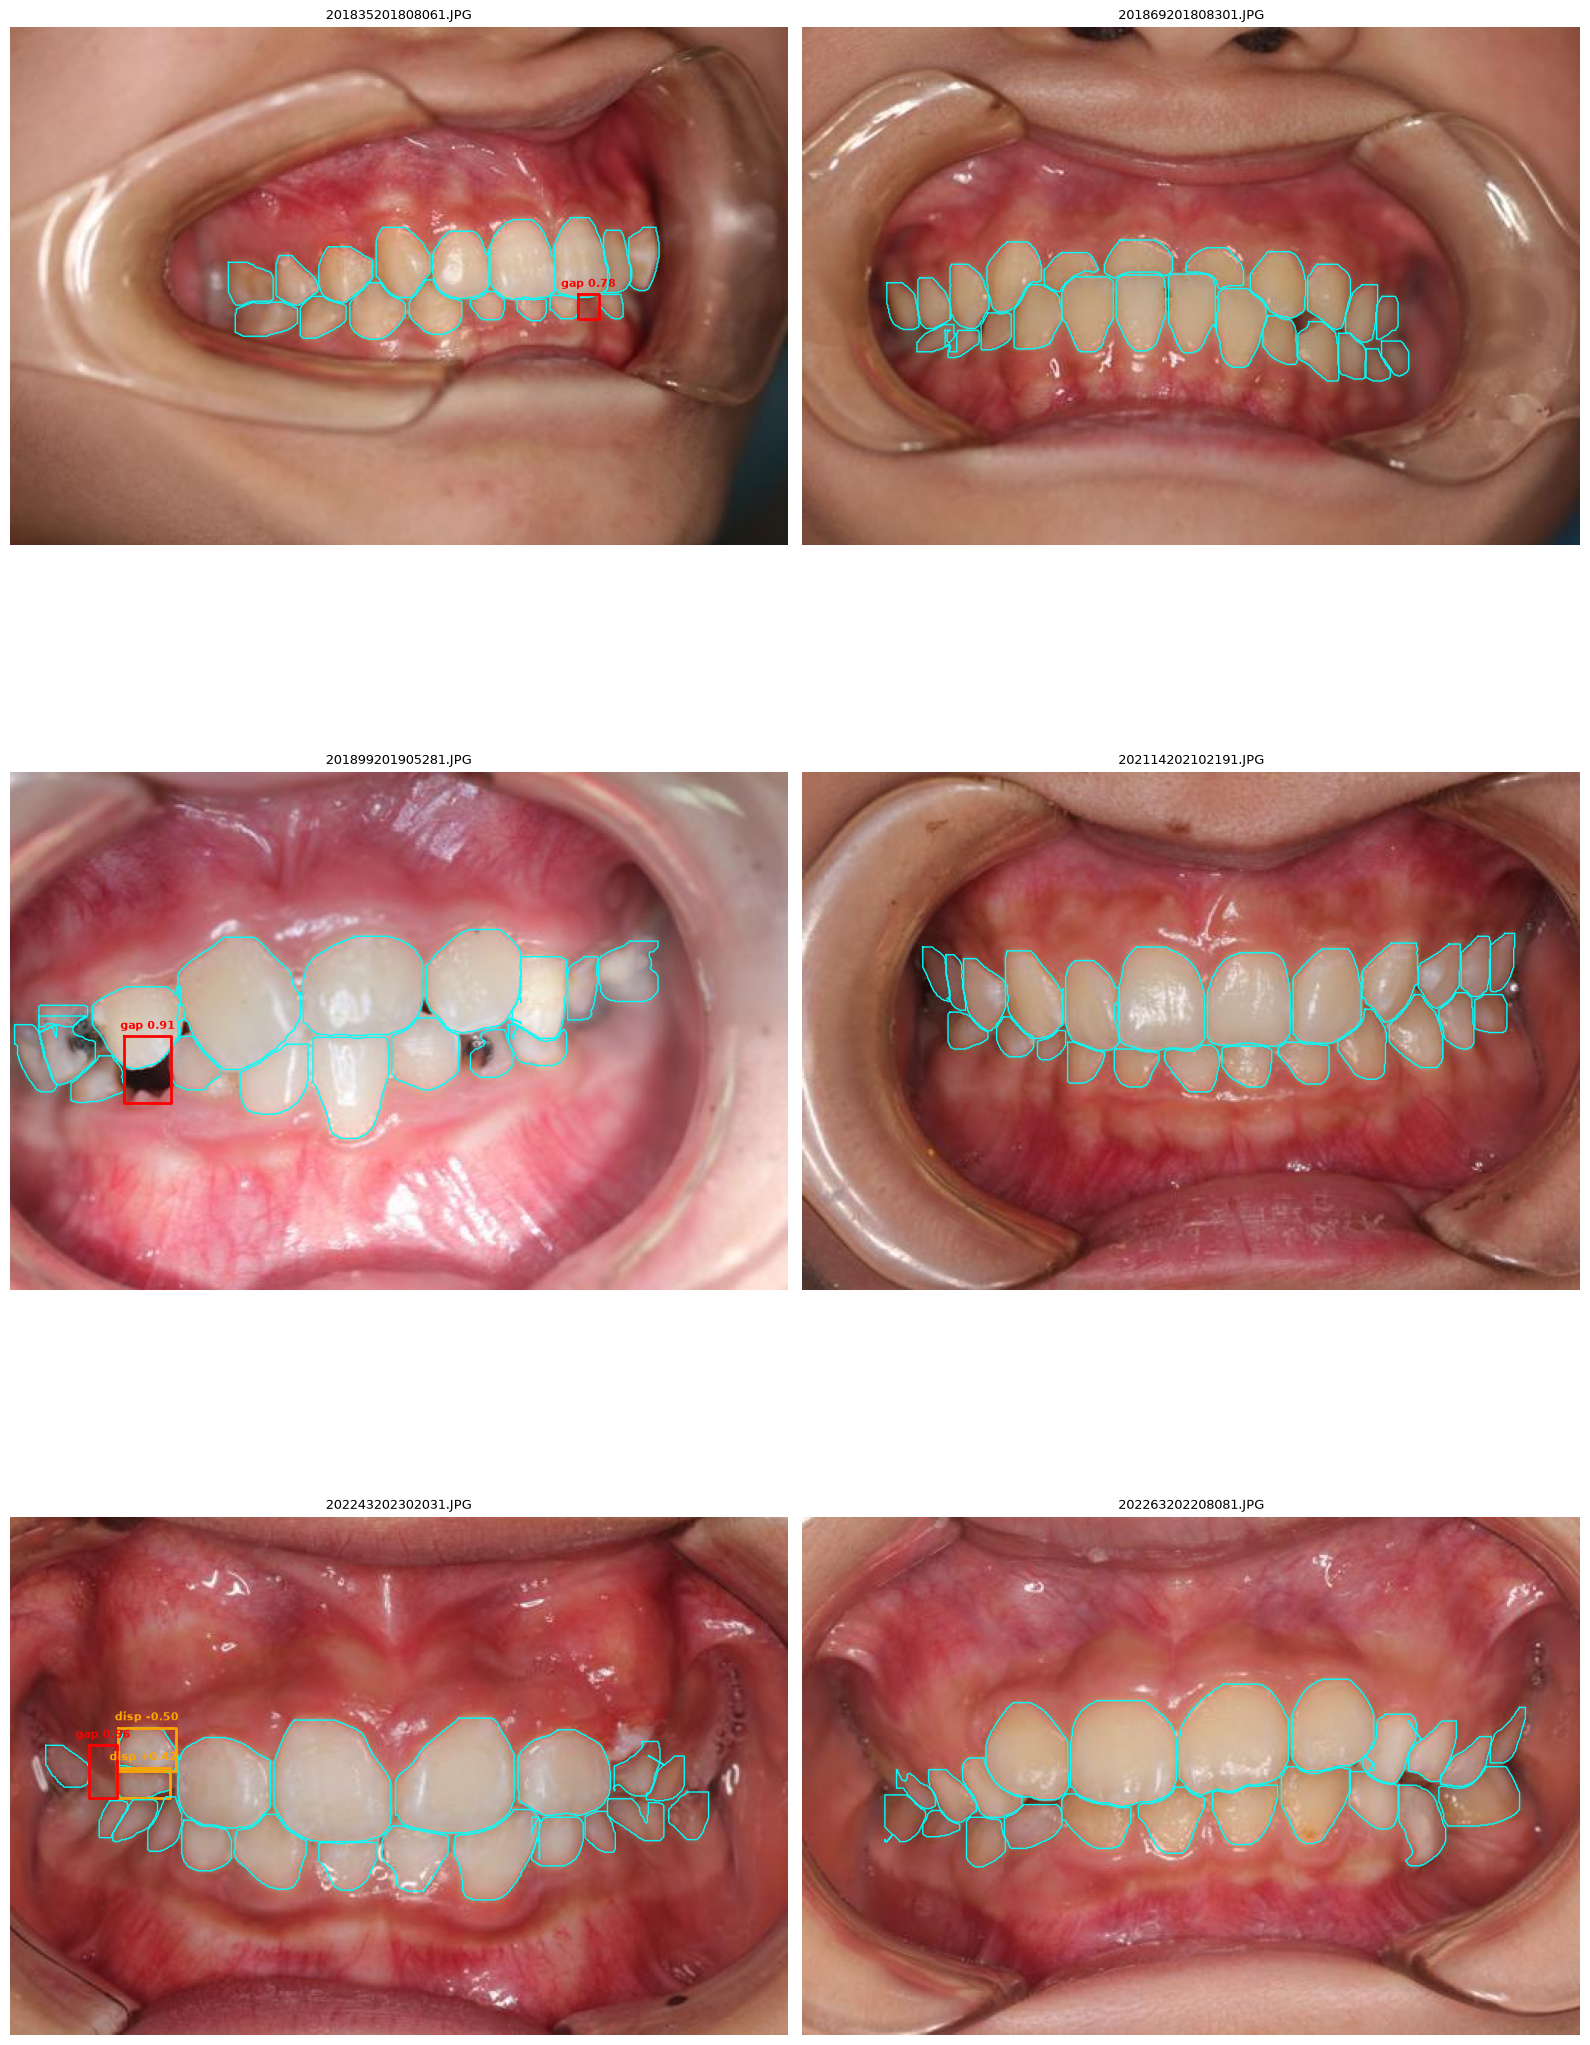

In [15]:
ncols = 2
nrows = (len(results) + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 8 * nrows))
axes = axes.reshape(-1)

for ax, r in zip(axes, results):
    ax.imshow(r["image"])
    for arch_name in ("upper", "lower"):
        for f in r[arch_name]:
            poly = f["points"]
            ax.plot(np.append(poly[:, 0], poly[0, 0]), np.append(poly[:, 1], poly[0, 1]), color="cyan", linewidth=1)
        for f, ratio in r["disp"][arch_name]:
            x0, y0, x1, y1 = f["bbox"]
            ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], color="orange", linewidth=2)
            ax.text(f["centroid"][0], y0 - 5, f"disp {ratio:+.2f}", color="orange", fontsize=8, ha="center", fontweight="bold")
        for a, b, ratio in r["gaps"][arch_name]:
            gx0, gx1 = a["bbox"][2], b["bbox"][0]
            gy0 = min(a["bbox"][1], b["bbox"][1])
            gy1 = max(a["bbox"][3], b["bbox"][3])
            ax.plot([gx0, gx1, gx1, gx0, gx0], [gy0, gy0, gy1, gy1, gy0], color="red", linewidth=2)
            ax.text((gx0 + gx1) / 2, gy0 - 5, f"gap {ratio:.2f}", color="red", fontsize=8, ha="center", fontweight="bold")
    ax.set_title(r["stem"], fontsize=9)
    ax.axis("off")
for ax in axes[len(results):]:
    ax.axis("off")
plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format="png", bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))